In [1]:
import numpy as np
import pandas as pd
from pandas.plotting import bootstrap_plot
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from tqdm.notebook import tqdm

from graphviz import Source #conda install python-graphviz
import pydotplus
from IPython.display import Image, display

random_state = 809

In [2]:
def show_tree(clf, feature_names=None, class_names=None):
    dot_data = tree.export_graphviz(clf, feature_names=feature_names, class_names=class_names, filled=True, rounded=True, out_file=None)
    graph = pydotplus.graph_from_dot_data(dot_data)
    display(Image(graph.create_png()))

# Loading a Dataset

In [3]:
X, y = make_classification(n_samples=1000,n_features=20, n_informative=15, shuffle=True, random_state=random_state)
df = pd.DataFrame(X, columns =['Variable '+str(i) for i in range(len(X[0]))])
variables = df.columns.tolist()
df['Outcome'] = y
df

,Variable 0,Variable 1,Variable 2,Variable 3,Variable 4,Variable 5,Variable 6,Variable 7,Variable 8,Variable 9,...,Variable 11,Variable 12,Variable 13,Variable 14,Variable 15,Variable 16,Variable 17,Variable 18,Variable 19,Outcome
0,-1.051323,0.804909,2.861989,-1.110437,-7.448280,-1.234328,1.170075,6.315246,-0.777915,-5.816210,...,-0.345604,2.030248,-4.834369,1.765350,2.277483,0.210833,6.160035,1.877318,3.325168,0
1,-1.429854,-0.407618,3.198294,-3.198525,1.358101,0.931401,1.512206,-7.807718,-0.262552,0.901626,...,-0.269404,-0.027260,2.558417,-1.226047,-2.920592,0.924220,-8.984699,4.961607,3.825588,1
2,2.027802,4.567615,-2.800876,-1.401196,1.258163,-1.259988,2.143692,-0.791760,-2.346354,-1.857481,...,-0.205177,-1.223625,-1.371234,0.648664,0.660507,0.367371,2.226927,-1.286205,-3.166889,1
3,0.405411,0.528841,2.328358,0.750853,0.431036,0.646702,-3.984091,2.609068,-1.092609,0.211696,...,1.076954,-0.813737,-1.951292,-4.943017,-1.761039,-0.723611,1.263877,-0.221904,-0.419399,0
4,-5.994016,1.198622,12.572893,1.232170,-0.801111,-0.734819,4.949027,1.674243,-2.964371,-3.806211,...,2.131154,0.330442,1.804794,-2.026046,-0.316309,-0.125813,-7.675988,3.830965,-0.273928,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-1.050593,3.654458,-6.247896,-3.174376,-0.963902,-2.200872,-0.438179,0.342268,-2.757844,-0.382242,...,1.980807,-0.762042,-5.988780,-2.280081,-5.369617,-0.057360,-0.082989,-1.603696,-2.025160,0
996,-0.090973,-0.958961,3.742747,3.365790,0.513783,0.206532,-0.498538,-4.342207,-2.005066,-6.294884,...,0.116336,1.036328,-1.975199,2.299417,0.856872,1.219831,9.295901,1.670809,2.008695,1
997,-2.217589,-1.197758,2.466439,-0.529596,2.840970,-0.587900,1.385040,1.829117,-2.541107,1.300387,...,0.824616,-1.608138,-0.493128,2.332137,-1.092136,-0.872568,-10.364850,1.719962,-0.527809,1
998,4.934138,1.451388,-3.189782,0.073861,0.749112,-0.390405,-3.774201,0.480763,-2.900395,-1.213851,...,0.540436,-0.174242,-2.060605,1.593035,-1.052057,0.626756,2.863755,0.115815,-1.517011,0


# Creating Bootstrapped Samples

In [4]:
nb_samples = 20
dfs_bootstraped= [df.sample(frac=1, replace=True, random_state=random_state+i) for i in range(nb_samples)]

### Looking at the Means:

In [5]:
df_means = pd.concat([df_bootstraped.mean() for df_bootstraped in dfs_bootstraped], axis = 1)
df_means.columns = [f'Sample {i+1}' for i in range(len(df_means.columns))]
df_means.T

,Variable 0,Variable 1,Variable 2,Variable 3,Variable 4,Variable 5,Variable 6,Variable 7,Variable 8,Variable 9,...,Variable 11,Variable 12,Variable 13,Variable 14,Variable 15,Variable 16,Variable 17,Variable 18,Variable 19,Outcome
Sample 1,0.705652,0.411066,0.055723,-0.413434,-0.134607,0.058262,0.111788,-0.072535,-0.502582,-0.665635,...,0.058291,-0.064404,-0.471805,0.525536,-0.050080,-0.053411,-0.204072,0.812812,0.452317,0.509
Sample 2,0.654142,0.412323,0.321501,-0.714295,0.057092,0.040266,0.103510,0.039346,-0.555352,-0.596917,...,-0.263494,-0.072013,-0.387590,0.473138,0.080341,-0.007781,-0.802451,1.040638,0.339117,0.469
Sample 3,0.535621,0.330459,0.285237,-0.585107,-0.072095,-0.031936,0.094613,0.146918,-0.572136,-0.441429,...,-0.133659,-0.007954,-0.506314,0.506196,-0.163906,0.030412,-1.035176,1.163586,0.472287,0.497
Sample 4,0.659982,0.470447,0.070781,-0.600990,0.014823,0.041728,0.116545,0.058181,-0.498095,-0.515482,...,0.014906,-0.025824,-0.559534,0.577612,0.007661,-0.019746,-0.615565,0.968928,0.341326,0.484
Sample 5,0.655958,0.579443,0.089883,-0.674206,-0.139275,0.039369,0.039655,0.168029,-0.590360,-0.442024,...,0.002047,-0.003262,-0.570587,0.534731,-0.095747,0.002332,-0.620824,0.868957,0.521073,0.477
Sample 6,0.627251,0.515957,0.077736,-0.644054,-0.107695,0.026123,0.162745,0.025522,-0.563662,-0.421267,...,-0.059034,0.017522,-0.454375,0.546195,-0.165421,0.034555,-0.850918,0.974365,0.502924,0.492
Sample 7,0.705845,0.522829,0.265693,-0.651845,-0.026872,0.032893,-0.070585,0.139218,-0.607028,-0.376775,...,-0.122883,0.010547,-0.450160,0.355636,-0.135934,-0.043518,-0.677075,0.881040,0.615312,0.480
Sample 8,0.633573,0.416086,0.182759,-0.618168,0.038913,0.011230,0.195361,0.108040,-0.650688,-0.497108,...,-0.081480,0.009073,-0.511793,0.584694,-0.013600,0.023771,-0.788387,0.940120,0.393436,0.466
Sample 9,0.719906,0.369261,-0.069229,-0.489542,0.072881,0.067653,0.152181,-0.048051,-0.501065,-0.588586,...,-0.122446,-0.054454,-0.603061,0.545033,-0.018335,-0.010596,-0.386314,0.977191,0.276453,0.493
Sample 10,0.669875,0.430291,0.348224,-0.464609,-0.048016,0.043341,0.033507,0.011682,-0.625303,-0.436125,...,-0.099269,-0.024804,-0.332733,0.426163,-0.112202,-0.002340,-0.761758,1.030449,0.413166,0.511


# Simple Tree Example
## On the initial Dataset

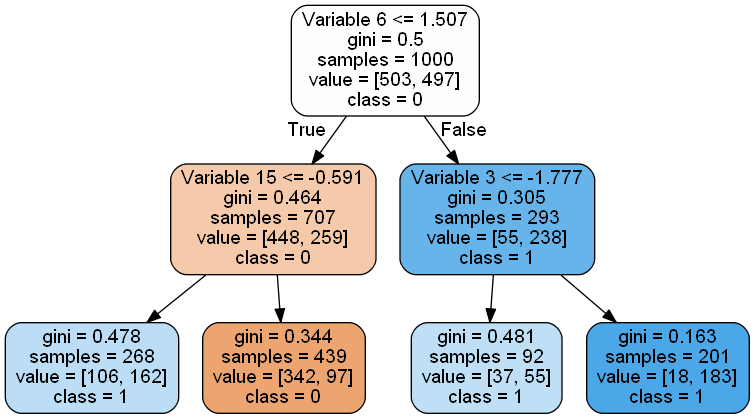

In [6]:
max_depth = 2
clf = tree.DecisionTreeClassifier(max_depth=max_depth, random_state=random_state)
clf = clf.fit(df[variables], df['Outcome'])
show_tree(clf, feature_names=variables, class_names =['0','1'])

## On the first bootstrapped sample

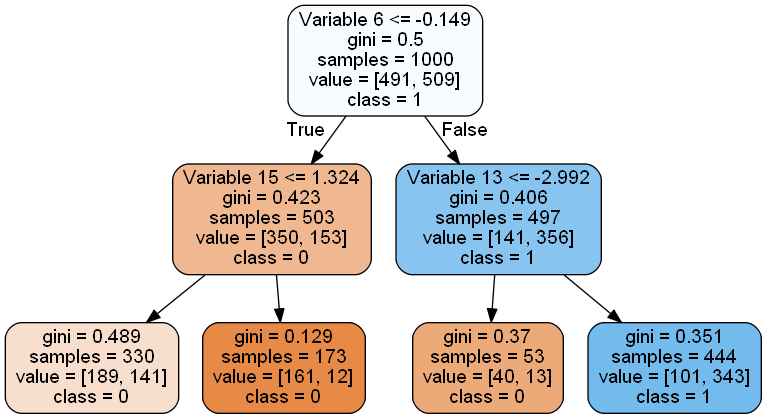

In [7]:
sample = 0
max_depth = 2

clf = tree.DecisionTreeClassifier(max_depth=2, random_state=random_state)
clf = clf.fit(dfs_bootstraped[sample][variables], dfs_bootstraped[sample]['Outcome'])
show_tree(clf, feature_names=variables, class_names =['0','1'])

### On the second sample

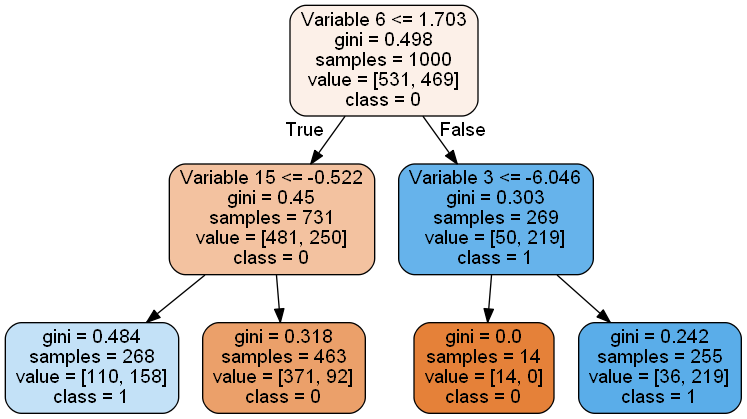

In [8]:
sample = 1
max_depth = 2

clf = tree.DecisionTreeClassifier(max_depth= max_depth, random_state=random_state)
clf = clf.fit(dfs_bootstraped[sample][variables], dfs_bootstraped[sample]['Outcome'])
show_tree(clf, feature_names=variables, class_names =['0','1'])

### Bagged Trees
We could run this for all samples we have and aggregate the results. The final predictions are made through a majority rule (i.e. if the majority of trees predict default, then we classify as default)

Those would be bagged trees. 

There is a way to do it in sklearn:

In [9]:
number_bagged_trees = 20
max_depth = 2
base_estimator=tree.DecisionTreeClassifier(max_depth= 2)

clf = BaggingClassifier(base_estimator, n_estimators=number_bagged_trees, random_state=random_state)
clf.fit(df[variables], df['Outcome'])

BaggingClassifier(base_estimator=DecisionTreeClassifier(max_depth=2),
                  n_estimators=20, random_state=809)

# Adding Randomness (Random subspace method)

At each split, in the basic tree model, the computer will consider all variables for splitting. But since we do not want every tree to look the same (otherwise, we would not gain much), we need to find a way to reduce the correlation between estimators.

When using a random subspace method, we only offer a subsample of all variables for splitting. This causes the trees to not over-focus on features that appear highly predictive in the training set. For example, if one variable appears to be very useful to rpedict default, in some splits, it may jsut not be avaialble and force the tree to chose a different one

In [10]:
max_depth = 2
sample = 0

### Considering ALL variables at each split (default)

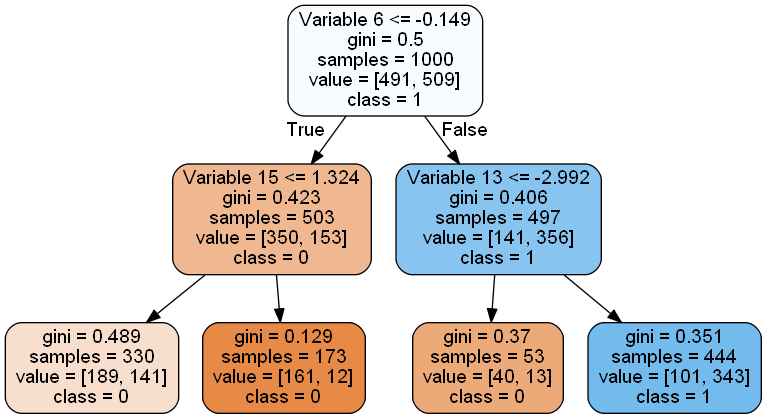

In [11]:
max_features = None

clf = tree.DecisionTreeClassifier(max_depth= max_depth, max_features=None, random_state=random_state)
clf.fit(dfs_bootstraped[sample][variables], dfs_bootstraped[sample]['Outcome'])
show_tree(clf, feature_names=variables, class_names =['0','1'])

### Considering ONLY a subset of variables at each split (default)
We set the hyperparameter max_features to sqrt meaning at each split we only consider $\sqrt 20\approx4$ variables for the splits (20 is the number of variables we have to chose from)

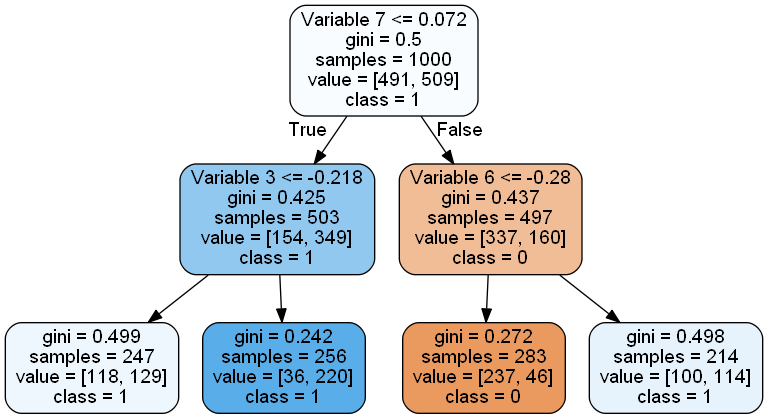

In [12]:
max_features='sqrt'

clf = tree.DecisionTreeClassifier(max_depth= 2, max_features=max_features, random_state=random_state)
clf.fit(dfs_bootstraped[sample][variables], dfs_bootstraped[sample]['Outcome'])
show_tree(clf, feature_names=variables, class_names =['0','1'])

# Putting it all together: Random Forests

In random forests, we combine Bagging with the random subspace method

### Hyperparameters
Like the trees, the random forests have many hyperparameters:
- The decision criterion (gini, entropy..)
- The max depth of the tree
- The minimum number of samples required to split an internal node
- The minimum number of samples required to be at a leaf node
- The number of trees in the forest
- The max number of features to be considered
- ...

In [13]:
clf = RandomForestClassifier(max_depth=None, random_state=random_state)
clf.fit(dfs_bootstraped[sample][variables], dfs_bootstraped[sample]['Outcome'])

parameters = clf.get_params()
print('The default parameters are:')
for key, item in parameters.items():
    print(f'- {key}: {item}')

The default parameters are:
- bootstrap: True
- ccp_alpha: 0.0
- class_weight: None
- criterion: gini
- max_depth: None
- max_features: auto
- max_leaf_nodes: None
- max_samples: None
- min_impurity_decrease: 0.0
- min_samples_leaf: 1
- min_samples_split: 2
- min_weight_fraction_leaf: 0.0
- n_estimators: 100
- n_jobs: None
- oob_score: False
- random_state: 809
- verbose: 0
- warm_start: False


### Optimizing the hyperparameters

In [14]:
n_estimators = [int(x) for x in np.linspace(start = 200, stop = 2000, num = 10)]
max_features = [0.5, 'sqrt']
max_depth = [int(x) for x in np.linspace(10, 110, num = 11)]
max_depth.append(None)
min_samples_split = [2, 5, 10]
min_samples_leaf = [1, 2, 4]

param_grid = {'n_estimators': n_estimators,
              'max_features': max_features,
              'max_depth': max_depth,
              'min_samples_split': min_samples_split,
              'min_samples_leaf': min_samples_leaf}

print('The parameters considered are:')
for key, item in param_grid.items():
    print(f'\t- {key}: {item}')

The parameters considered are:
	- n_estimators: [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000]
	- max_features: [0.5, 'sqrt']
	- max_depth: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, None]
	- min_samples_split: [2, 5, 10]
	- min_samples_leaf: [1, 2, 4]


In [15]:
number_iters = np.prod([len(item) for key, item in param_grid.items()])
print(f'To select the right combination of hyperparamters, we would have to run {number_iters} random forests')

To select the right combination of hyperparamters, we would have to run 2160 random forests


### This would take a  long time through a grid search (GridSearchCv as we have seen before)
An alternative is to search randomly through the parameter list

In [16]:
clf = RandomForestClassifier()
n_iter = 20 # Number of parameter settings that are sampled. n_iter trades off runtime vs quality of the solution.
cv = 3 #Crossvalidation folds
n_jobs = -1 #Uses all cores available
verbose = 5 #controls how much the algo will print text to inform us of what is going on

rf_random = RandomizedSearchCV(estimator = clf, param_distributions = param_grid, 
                               n_iter = n_iter, cv = cv, verbose=verbose, 
                               random_state=random_state, n_jobs = n_jobs)
rf_random.fit(dfs_bootstraped[sample][variables], dfs_bootstraped[sample]['Outcome'])

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(), n_iter=20,
                   n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, 30, 40, 50, 60,
                                                      70, 80, 90, 100, 110,
                                                      None],
                                        'max_features': [0.5, 'sqrt'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [200, 400, 600, 800,
                                                         1000, 1200, 1400, 1600,
                                                         1800, 2000]},
                   random_state=809, verbose=5)

In [17]:
best_parameters = rf_random.best_params_
print('The best Parameters are:')
for key, item in best_parameters.items():
    print(f'- {key}: {item}')

The best Parameters are:
- n_estimators: 1000
- min_samples_split: 2
- min_samples_leaf: 4
- max_features: sqrt
- max_depth: 40


In [18]:
#But it only considred the following paramters:
print(f'But note that we have considered {len(rf_random.cv_results_["params"])} combinations:')
df_params = pd.DataFrame(rf_random.cv_results_['params'])
df_params

But note that we have considered 20 combinations:


,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth
0,400,2,1,sqrt,80.0
1,800,5,1,0.5,100.0
2,1800,10,2,sqrt,80.0
3,800,10,2,sqrt,NaN
4,2000,10,1,0.5,100.0
5,400,5,1,sqrt,100.0
6,600,5,4,sqrt,30.0
7,1400,5,2,0.5,90.0
8,800,2,4,0.5,20.0
9,1800,10,2,0.5,30.0
